
<div style="background-color: #eddcd4ff; padding: 10px; border-radius: 5px; border-left: 4px solid #a77428ff;">
<h2 style="color: #572415ff; margin: 0;">Importation des bibliothéque et pandas et visualisation</h2>
</div>

In [47]:
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np



<div style="background-color: #eddcd4ff; padding: 10px; border-radius: 5px; border-left: 4px solid #a77428ff;">
<h2 style="color: #572415ff; margin: 0;">Compréhension des données</h2>
</div>

In [48]:
df = pd.read_csv('datauber.csv')
df.head(10)

,Unnamed: 0,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
0,24238194.0,2015-05-07 19:52:06.0000003,7.5,2015-05-07 19:52:06 UTC,-73.999817,40.738354,-73.999512,40.723217,1.0
1,27835199.0,2009-07-17 20:04:56.0000002,7.7,2009-07-17 20:04:56 UTC,-73.994355,40.728225,-73.994710,40.750325,1.0
2,44984355.0,2009-08-24 21:45:00.00000061,12.9,NaN,-74.005043,40.740770,NaN,40.772647,1.0
3,25894730.0,2009-06-26 08:22:21.0000001,5.3,2009-06-26 08:22:21 UTC,-73.976124,NaN,-73.965316,40.803349,3.0
4,17610152.0,2014-08-28 17:47:00.000000188,16.0,2014-08-28 17:47:00 UTC,NaN,40.744085,-73.973082,NaN,5.0
5,44470845.0,2011-02-12 02:27:09.0000006,4.9,2011-02-12 02:27:09 UTC,-73.969019,40.755910,-73.969019,40.755910,1.0
6,48725865.0,2014-10-12 07:04:00.0000002,24.5,2014-10-12 07:04:00 UTC,NaN,40.693965,-73.871195,40.774297,5.0
7,44195482.0,2012-12-11 13:52:00.00000029,2.5,2012-12-11 13:52:00 UTC,0.000000,0.000000,0.000000,0.000000,1.0
8,15822268.0,2012-02-17 09:32:00.00000043,9.7,2012-02-17 09:32:00 UTC,-73.975187,40.745767,-74.002720,40.743537,1.0
9,50611056.0,2012-03-29 19:06:00.000000273,12.5,2012-03-29 19:06:00 UTC,-74.001065,40.741787,-73.963040,NaN,1.0


In [49]:
df.columns

Index(['Unnamed: 0', 'key', 'fare_amount', 'pickup_datetime',
       'pickup_longitude', 'pickup_latitude', 'dropoff_longitude',
       'dropoff_latitude', 'passenger_count'],
      dtype='object')

In [50]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44377 entries, 0 to 44376
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         42243 non-null  float64
 1   key                42143 non-null  object 
 2   fare_amount        42217 non-null  float64
 3   pickup_datetime    42094 non-null  object 
 4   pickup_longitude   42183 non-null  float64
 5   pickup_latitude    42130 non-null  float64
 6   dropoff_longitude  42183 non-null  float64
 7   dropoff_latitude   42119 non-null  float64
 8   passenger_count    42159 non-null  float64
dtypes: float64(7), object(2)
memory usage: 3.0+ MB


<div style="background-color: #eddcd4ff; padding: 10px; border-radius: 5px; border-left: 4px solid #a77428ff;">
<h2 style="color: #572415ff; margin: 0;">Nettoyage des données</h2>
</div>

<div style="background-color: #dfedd4ff; padding: 10px; border-radius: 5px; border-left: 4px solid #3ba728ff;">
<h3 style="color: #15574fff; margin: 0;">detection des doublons</h3>
</div>

In [51]:

print("Total des doublons (sans la première occurrence) :", df.duplicated(keep='first').sum())# Supprimer les doublons en gardant la première occurrence
df = df.drop_duplicates(keep='first')
print(f"Taille du dataset APRÈS suppression des doublons : {len(df)}")
print("Doublons supprimés avec succès!")

Total des doublons (sans la première occurrence) : 105
Taille du dataset APRÈS suppression des doublons : 44272
Doublons supprimés avec succès!


<div style="background-color: #dfedd4ff; padding: 10px; border-radius: 5px; border-left: 4px solid #3ba728ff;">
<h3 style="color: #15574fff; margin: 0;">Nettoyer les valeurs pickup_datetime</h3>
</div>

<div style="background-color: #dfedd4ff; padding: 10px; border-radius: 5px; border-left: 4px solid #3ba728ff;">
<h4 style="color: #15574fff; margin: 0;">imputer les valeurs null de pickup_datetime avec key valeurs</h4>
</div>

In [52]:
df["key"].isnull().sum()

2232

In [53]:
df['pickup_datetime'].isna().sum()

2277

In [54]:




# 3. Parser key -> datetime (on force aussi utc=True)
df['key'] = pd.to_datetime(df['key'], utc=True, errors='coerce')

# 4. Masque des lignes où on peut remplir
mask_fill = df['pickup_datetime'].isna() & df['key'].notna()

# 5. Remplissage
df.loc[mask_fill, 'pickup_datetime'] = df.loc[mask_fill, 'key']

print("Lignes remplies depuis key :", mask_fill.sum())
print("NaN pickup_datetime APRES  :", df['pickup_datetime'].isna().sum())





Lignes remplies depuis key : 2151
NaN pickup_datetime APRES  : 126


<div style="background-color: #dfedd4ff; padding: 10px; border-radius: 5px; border-left: 4px solid #3ba728ff;">
<h4 style="color: #15574fff; margin: 0;">supprimer les lignes non imputé</h4>
</div>

In [55]:
# Supprimer les lignes où pickup_datetime est NaN
df = df.dropna(subset=['pickup_datetime'])
df.head()

,Unnamed: 0,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
0,24238194.0,2015-05-07 19:52:06.000000300+00:00,7.5,2015-05-07 19:52:06 UTC,-73.999817,40.738354,-73.999512,40.723217,1.0
1,27835199.0,2009-07-17 20:04:56.000000200+00:00,7.7,2009-07-17 20:04:56 UTC,-73.994355,40.728225,-73.994710,40.750325,1.0
2,44984355.0,2009-08-24 21:45:00.000000610+00:00,12.9,2009-08-24 21:45:00.000000610+00:00,-74.005043,40.740770,NaN,40.772647,1.0
3,25894730.0,2009-06-26 08:22:21.000000100+00:00,5.3,2009-06-26 08:22:21 UTC,-73.976124,NaN,-73.965316,40.803349,3.0
4,17610152.0,2014-08-28 17:47:00.000000188+00:00,16.0,2014-08-28 17:47:00 UTC,NaN,40.744085,-73.973082,NaN,5.0


In [56]:
df.head()

,Unnamed: 0,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
0,24238194.0,2015-05-07 19:52:06.000000300+00:00,7.5,2015-05-07 19:52:06 UTC,-73.999817,40.738354,-73.999512,40.723217,1.0
1,27835199.0,2009-07-17 20:04:56.000000200+00:00,7.7,2009-07-17 20:04:56 UTC,-73.994355,40.728225,-73.994710,40.750325,1.0
2,44984355.0,2009-08-24 21:45:00.000000610+00:00,12.9,2009-08-24 21:45:00.000000610+00:00,-74.005043,40.740770,NaN,40.772647,1.0
3,25894730.0,2009-06-26 08:22:21.000000100+00:00,5.3,2009-06-26 08:22:21 UTC,-73.976124,NaN,-73.965316,40.803349,3.0
4,17610152.0,2014-08-28 17:47:00.000000188+00:00,16.0,2014-08-28 17:47:00 UTC,NaN,40.744085,-73.973082,NaN,5.0


<div style="background-color: #dfedd4ff; padding: 10px; border-radius: 5px; border-left: 4px solid #3ba728ff;">
<h3 style="color: #15574fff; margin: 0;">supprimer les valeurs manquantes pour pickup_longitude et lattitude</h3>
</div>

In [57]:
df["pickup_latitude"].isnull().sum(), df["pickup_longitude"].isnull().sum()

(2234, 2181)

In [58]:
df = df.dropna(subset=['pickup_longitude', 'pickup_latitude'])

In [59]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 39811 entries, 0 to 44269
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype              
---  ------             --------------  -----              
 0   Unnamed: 0         37867 non-null  float64            
 1   key                37921 non-null  datetime64[ns, UTC]
 2   fare_amount        37871 non-null  float64            
 3   pickup_datetime    39811 non-null  object             
 4   pickup_longitude   39811 non-null  float64            
 5   pickup_latitude    39811 non-null  float64            
 6   dropoff_longitude  37827 non-null  float64            
 7   dropoff_latitude   37795 non-null  float64            
 8   passenger_count    37812 non-null  float64            
dtypes: datetime64[ns, UTC](1), float64(7), object(1)
memory usage: 3.0+ MB


<div style="background-color: #dfedd4ff; padding: 10px; border-radius: 5px; border-left: 4px solid #3ba728ff;">
<h3 style="color: #15574fff; margin: 0;">detection des valeurs aberrantes pour passenger_count et fare_amount</h3>
</div>

In [60]:
print("=== ANALYSE passenger_count ===")
print("Valeurs uniques :", sorted(df['passenger_count'].unique()))

=== ANALYSE passenger_count ===
Valeurs uniques : [0.0, 1.0, 2.0, 3.0, 4.0, 5.0, nan, 6.0]


In [61]:
print("Statistiques :")
print(df['passenger_count'].describe())


Statistiques :
count    37812.000000
mean         1.680049
std          1.299030
min          0.000000
25%          1.000000
50%          1.000000
75%          2.000000
max          6.000000
Name: passenger_count, dtype: float64


In [62]:
print("\n=== ANALYSE fare_amount ===")
print("Statistiques :")
print(df['fare_amount'].describe())
print(f"\nValeurs négatives : {(df['fare_amount'] < 0).sum()}")
print(f"Valeurs = 0 : {(df['fare_amount'] == 0).sum()}")
print(f"Valeurs > 100$ : {(df['fare_amount'] > 100).sum()}")


=== ANALYSE fare_amount ===
Statistiques :
count    37871.000000
mean        11.419834
std         10.148646
min          0.000000
25%          6.000000
50%          8.500000
75%         12.900000
max        350.000000
Name: fare_amount, dtype: float64

Valeurs négatives : 0
Valeurs = 0 : 2
Valeurs > 100$ : 23


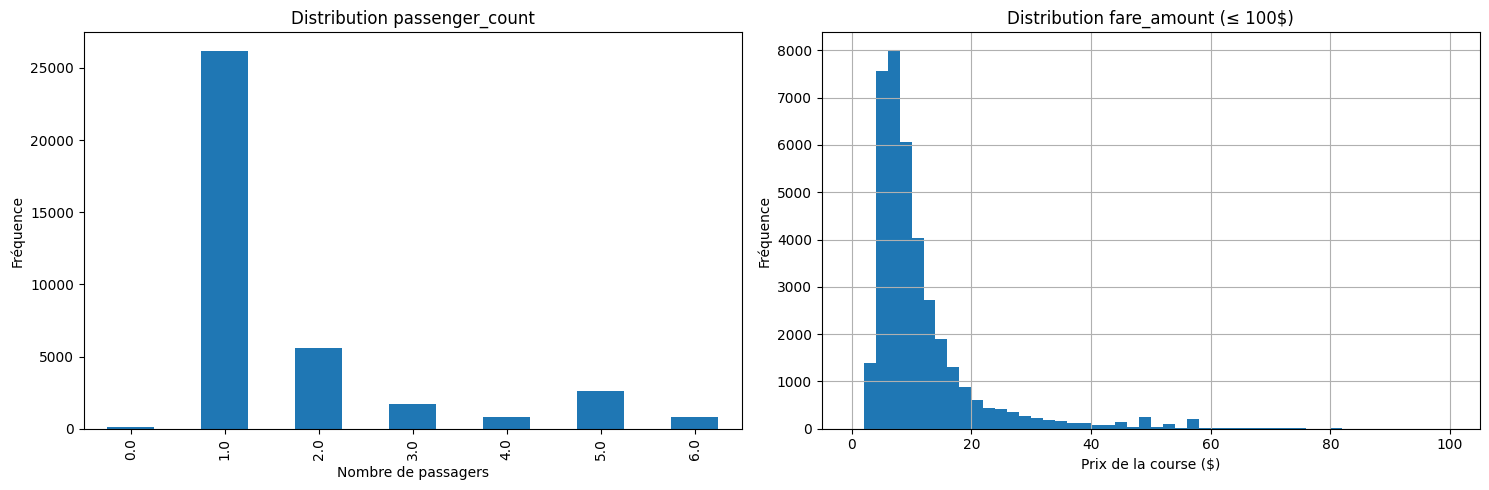

In [63]:
# Visualisation des distributions
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# passenger_count
df['passenger_count'].value_counts().sort_index().plot(kind='bar', ax=ax1)
ax1.set_title("Distribution passenger_count")
ax1.set_xlabel("Nombre de passagers")
ax1.set_ylabel("Fréquence")

# fare_amount (avec focus sur valeurs raisonnables)
df[df['fare_amount'] <= 100]['fare_amount'].hist(bins=50, ax=ax2)
ax2.set_title("Distribution fare_amount (≤ 100$)")
ax2.set_xlabel("Prix de la course ($)")
ax2.set_ylabel("Fréquence")

plt.tight_layout()
plt.show()

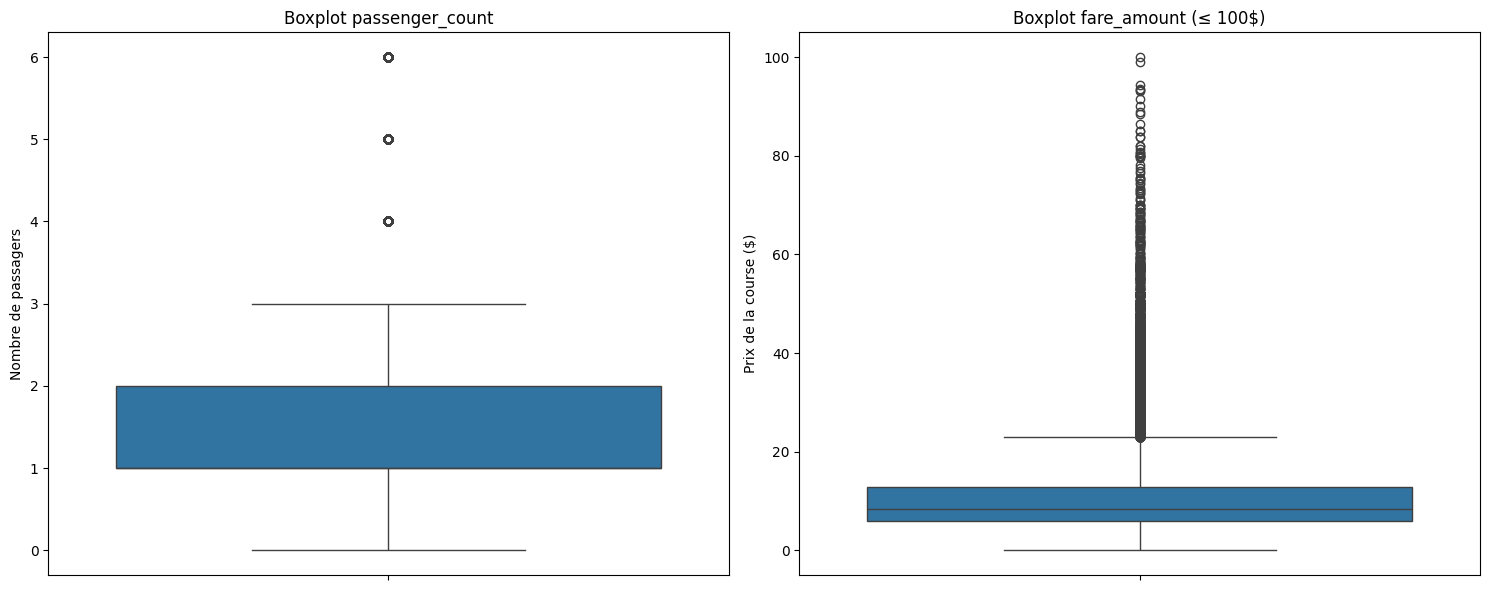

In [64]:
# Créer des boxplots pour visualiser les outliers
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Boxplot passenger_count
sns.boxplot(data=df, y='passenger_count', ax=ax1)
ax1.set_title("Boxplot passenger_count")
ax1.set_ylabel("Nombre de passagers")

# Boxplot fare_amount (limité à 100$ pour la visibilité)
sns.boxplot(data=df[df['fare_amount'] <= 100], y='fare_amount', ax=ax2)
ax2.set_title("Boxplot fare_amount (≤ 100$)")
ax2.set_ylabel("Prix de la course ($)")

plt.tight_layout()
plt.show()

In [65]:
print(f"\nValeurs superieur à 3 : {(df['passenger_count'] > 3).sum()}")
print(f"Valeurs superieur à 30 : {(df['fare_amount'] > 30).sum()}")


Valeurs superieur à 3 : 4195
Valeurs superieur à 30 : 1914


<div style="background-color: #dfedd4ff; padding: 10px; border-radius: 5px; border-left: 4px solid #3ba728ff;">
<h4 style="color: #15574fff; margin: 0;">supprimer les valeurs aberrantes pour fare_amount et passenger_count</h4>
</div>

In [66]:
# Suppression des valeurs aberrantes
# Critères logiques pour un service de taxi NYC :
df_clean = df[
    (df['passenger_count'] >= 1) & (df['passenger_count'] <= 6) &  # 1-6 passagers
    (df['fare_amount'] > 0) & (df['fare_amount'] <= 150)           # 0.01-150$ raisonnable
].copy()

print(f"\nTaille dataset APRES nettoyage : {len(df_clean)}")
print(f"Lignes supprimées : {len(df) - len(df_clean)}")
print(f"Pourcentage supprimé : {((len(df) - len(df_clean)) / len(df)) * 100:.2f}%")

# Mise à jour
df = df_clean


Taille dataset APRES nettoyage : 35834
Lignes supprimées : 3977
Pourcentage supprimé : 9.99%


<div style="background-color: #dfedd4ff; padding: 10px; border-radius: 5px; border-left: 4px solid #3ba728ff;">
<h4 style="color: #15574fff; margin: 0;">detection des valeurs aberrantes pour pickup_longitude et lattitude</h4>
</div>

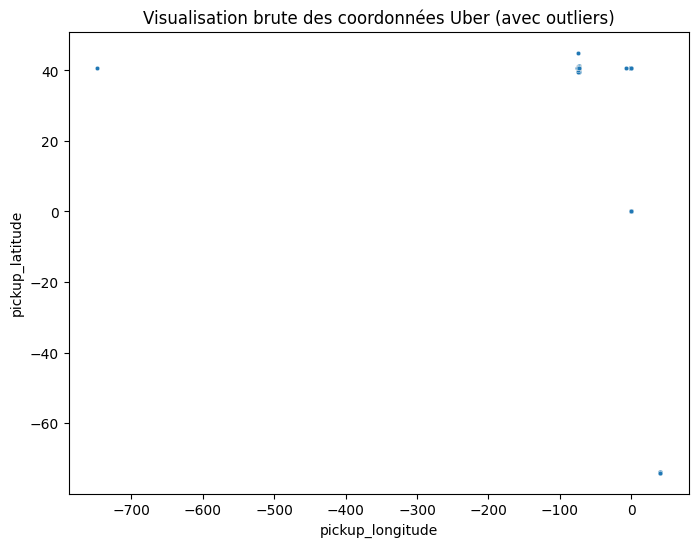

In [67]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x='pickup_longitude', y='pickup_latitude', s=10)
plt.title("Visualisation brute des coordonnées Uber (avec outliers)")
plt.show()


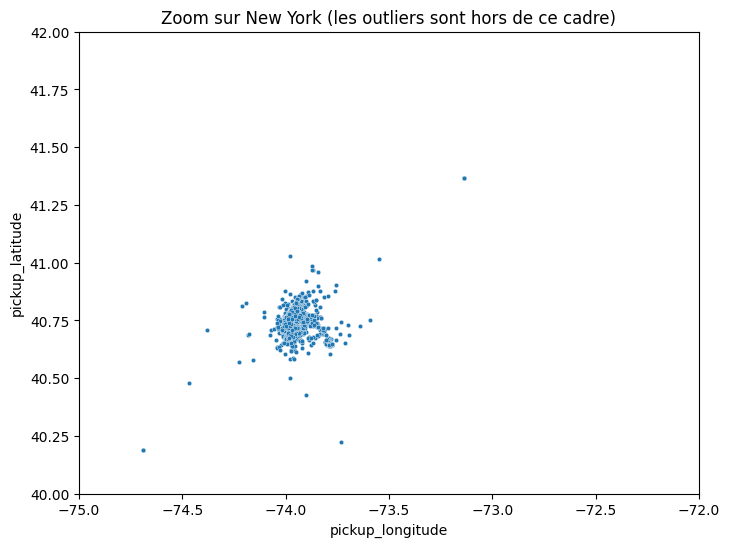

In [68]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x='pickup_longitude', y='pickup_latitude', s=10)
plt.xlim(-75, -72)   # limites longitude New York
plt.ylim(40, 42)     # limites latitude New York
plt.title("Zoom sur New York (les outliers sont hors de ce cadre)")
plt.show()


<div style="background-color: #dfedd4ff; padding: 10px; border-radius: 5px; border-left: 4px solid #3ba728ff;">
<h4 style="color: #15574fff; margin: 0;">detection des valeurs aberrantes de pickup_lattitude et longitude</h4>
</div>

In [69]:
df = df[
    (df['pickup_longitude'] > -75) & (df['pickup_longitude'] < -73.2) &
    (df['pickup_latitude'] > 40) & (df['pickup_latitude'] < 42)
]


In [70]:
df[
    (df['pickup_longitude'] < -75) | (df['pickup_longitude'] > -73.2) &
    (df['pickup_latitude'] < 40) | (df['pickup_latitude'] > 42)
].head()


,Unnamed: 0,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count


<div style="background-color: #eddcd4ff; padding: 10px; border-radius: 5px; border-left: 4px solid #a77428ff;">
<h2 style="color: #572415ff; margin: 0;">Feature engineering</h2>
</div>

<div style="background-color: #dfedd4ff; padding: 10px; border-radius: 5px; border-left: 4px solid #3ba728ff;">
<h4 style="color: #15574fff; margin: 0;">suppression des colonnes non nécessaires</h4>
</div>

In [71]:
df = df.drop(columns=['Unnamed: 0', 'key',  
                      'dropoff_longitude', 'dropoff_latitude'
                      ])

In [72]:
df.head()

,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,passenger_count
0,7.5,2015-05-07 19:52:06 UTC,-73.999817,40.738354,1.0
1,7.7,2009-07-17 20:04:56 UTC,-73.994355,40.728225,1.0
2,12.9,2009-08-24 21:45:00.000000610+00:00,-74.005043,40.740770,1.0
5,4.9,2011-02-12 02:27:09 UTC,-73.969019,40.755910,1.0
8,9.7,2012-02-17 09:32:00 UTC,-73.975187,40.745767,1.0


<div style="background-color: #dfedd4ff; padding: 10px; border-radius: 5px; border-left: 4px solid #3ba728ff;">
<h4 style="color: #15574fff; margin: 0;">extraire mois , saison , jours ,heures à partir pickup_datetime</h4>
</div>

In [73]:
# Convertir la colonne pickup_datetime en format datetime (UTC compris)
df['pickup_datetime'] = pd.to_datetime(df['pickup_datetime'], errors='coerce')
df.head()

,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,passenger_count
0,7.5,2015-05-07 19:52:06+00:00,-73.999817,40.738354,1.0
1,7.7,2009-07-17 20:04:56+00:00,-73.994355,40.728225,1.0
2,12.9,2009-08-24 21:45:00.000000610+00:00,-74.005043,40.740770,1.0
5,4.9,2011-02-12 02:27:09+00:00,-73.969019,40.755910,1.0
8,9.7,2012-02-17 09:32:00+00:00,-73.975187,40.745767,1.0


In [74]:
df['hour']= df['pickup_datetime'].dt.hour
df['day']= df['pickup_datetime'].dt.day_of_week
df['month']= df['pickup_datetime'].dt.month
def get_season(month):
    if month in [12, 1, 2]:
        return 'winter'
    elif month in [3, 4, 5]:
        return 'spring'
    elif month in [6, 7, 8]:
        return 'summer'
    else:
        return 'autumn'

df['season'] = df['month'].apply(get_season)


In [75]:
df.drop(columns=['pickup_datetime'], inplace=True)

<div style="background-color: #dfedd4ff; padding: 10px; border-radius: 5px; border-left: 4px solid #3ba728ff;">
<h4 style="color: #15574fff; margin: 0;">Visualisation des données pour le clustering</h4>
</div>

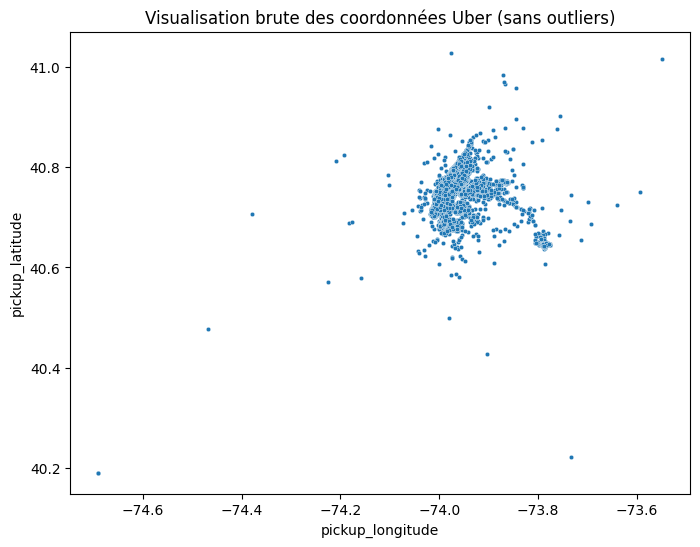

In [76]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x='pickup_longitude', y='pickup_latitude', s=10)
plt.title("Visualisation brute des coordonnées Uber (sans outliers)")
plt.show()


<div style="background-color: #eddcd4ff; padding: 10px; border-radius: 5px; border-left: 4px solid #a77428ff;">
<h2 style="color: #572415ff; margin: 0;">Importation du model HDBSCAN</h2>
</div>

In [77]:
import hdbscan

<div style="background-color: #dfedd4ff; padding: 10px; border-radius: 5px; border-left: 4px solid #3ba728ff;">
<h4 style="color: #15574fff; margin: 0;">Entrainer le model</h4>
</div>

In [78]:


coords_rad = np.radians(df[['pickup_latitude','pickup_longitude']].values)
hdb = hdbscan.HDBSCAN(min_cluster_size=250, min_samples=2, metric='haversine',prediction_data=True)
df['cluster'] = hdb.fit_predict(coords_rad)

<div style="background-color: #dfedd4ff; padding: 10px; border-radius: 5px; border-left: 4px solid #3ba728ff;">
<h4 style="color: #15574fff; margin: 0;">Visualiser le resultat</h4>
</div>

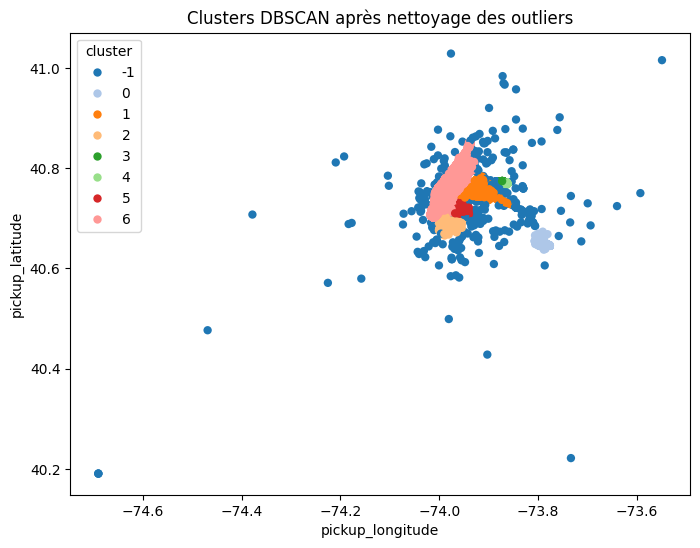

In [79]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x='pickup_longitude', y='pickup_latitude',
                hue='cluster', palette='tab20', linewidth=0)
plt.title("Clusters DBSCAN après nettoyage des outliers")
plt.show()


<div style="background-color: #dfedd4ff; padding: 10px; border-radius: 5px; border-left: 4px solid #3ba728ff;">
<h4 style="color: #15574fff; margin: 0;">suppresions des valeurs aberrantes</h4>
</div>

In [80]:
df[df['cluster'] == -1].info()


<class 'pandas.core.frame.DataFrame'>
Index: 357 entries, 383 to 43823
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   fare_amount       357 non-null    float64
 1   pickup_longitude  357 non-null    float64
 2   pickup_latitude   357 non-null    float64
 3   passenger_count   357 non-null    float64
 4   hour              357 non-null    int32  
 5   day               357 non-null    int32  
 6   month             357 non-null    int32  
 7   season            357 non-null    object 
 8   cluster           357 non-null    int64  
dtypes: float64(4), int32(3), int64(1), object(1)
memory usage: 23.7+ KB


In [81]:
df[df['cluster'] ==6].info()

<class 'pandas.core.frame.DataFrame'>
Index: 32431 entries, 0 to 44269
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   fare_amount       32431 non-null  float64
 1   pickup_longitude  32431 non-null  float64
 2   pickup_latitude   32431 non-null  float64
 3   passenger_count   32431 non-null  float64
 4   hour              32431 non-null  int32  
 5   day               32431 non-null  int32  
 6   month             32431 non-null  int32  
 7   season            32431 non-null  object 
 8   cluster           32431 non-null  int64  
dtypes: float64(4), int32(3), int64(1), object(1)
memory usage: 2.1+ MB


In [82]:
df = df[df["cluster"] != -1]

<div style="background-color: #dfedd4ff; padding: 10px; border-radius: 5px; border-left: 4px solid #3ba728ff;">
<h4 style="color: #15574fff; margin: 0;">Visualisation du resultat final</h4>
</div>

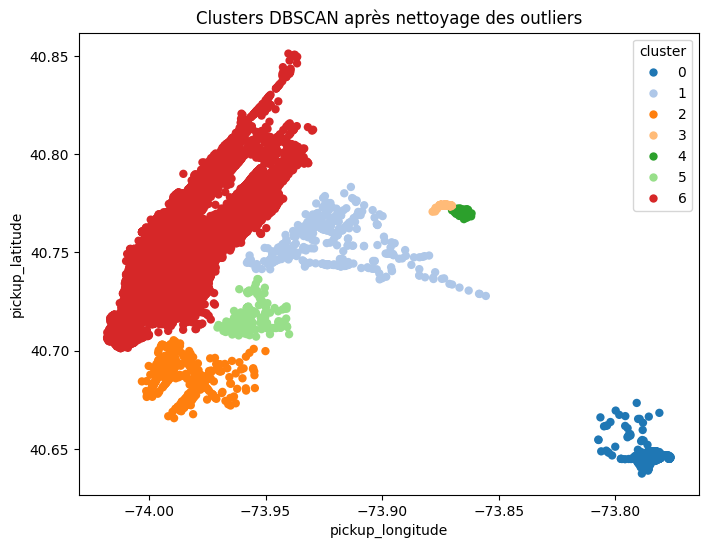

In [83]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x='pickup_longitude', y='pickup_latitude',
                hue='cluster', palette='tab20', linewidth=0)
plt.title("Clusters DBSCAN après nettoyage des outliers")
plt.show()


<div style="background-color: #eddcd4ff; padding: 10px; border-radius: 5px; border-left: 4px solid #a77428ff;">
<h2 style="color: #572415ff; margin: 0;">Visualisation des clusters sur la map</h2>
</div>

In [84]:
import folium
from folium import plugins
import numpy as np

# Créer une carte centrée sur New York
# Calculer le centre géographique de nos données
center_lat = df['pickup_latitude'].mean()
center_lon = df['pickup_longitude'].mean()

# Initialiser la carte interactive avec zoom approprié
m = folium.Map(
    location=[center_lat, center_lon],  # Centre de la carte
    zoom_start=11,                      # Niveau de zoom initial
    tiles='OpenStreetMap'               # Type de tuiles (fond de carte)
)

# Définir une palette de couleurs pour les clusters
colors = ['red', 'blue', 'green', 'purple', 'orange', 'darkred', 
          'lightred', 'beige', 'darkblue', 'darkgreen', 'cadetblue', 
          'darkpurple', 'white', 'pink', 'lightblue', 'lightgreen', 
          'gray', 'black', 'lightgray']

# Échantillonner les données pour éviter la surcharge (optionnel)
sample_size = 5000  # Ajustez selon vos besoins
if len(df) > sample_size:
    df_sample = df.sample(n=sample_size, random_state=42)
else:
    df_sample = df

# Ajouter les points colorés par cluster
for cluster_id in sorted(df_sample['cluster'].unique()):
    # Filtrer les données pour le cluster actuel
    cluster_data = df_sample[df_sample['cluster'] == cluster_id]
    
    # Choisir une couleur pour ce cluster
    color = colors[cluster_id]
    
    # Ajouter chaque point du cluster à la carte
    for idx, row in cluster_data.iterrows():
        folium.CircleMarker(
            location=[row['pickup_latitude'], row['pickup_longitude']],
            radius=3,                    # Taille du marqueur
            popup=f'Cluster {cluster_id}<br>'  # Info-bulle au clic
                  f'Heure: {row["hour"]}h<br>'
                  f'Mois: {row["month"]}<br>'
                  f'Saison: {row["season"]}',
            color=color,                 # Couleur du contour
            fill=True,                   # Remplissage du cercle
            fillColor=color,             # Couleur de remplissage
            fillOpacity=0.7,             # Transparence du remplissage
            weight=1                     # Épaisseur du contour
        ).add_to(m)

# Ajouter une légende des clusters
legend_html = '''
<div style="position: fixed; 
            top: 10px; right: 10px; width: 150px; height: auto; 
            background-color: white; border:2px solid grey; z-index:9999; 
            font-size:14px; padding: 10px">
<h4>Clusters</h4>
'''
for i, cluster_id in enumerate(sorted(df['cluster'].unique())):
    color = colors[cluster_id % len(colors)]
    count = len(df[df['cluster'] == cluster_id])
    legend_html += f'<p><span style="color:{color};">●</span> Cluster {cluster_id} ({count} points)</p>'

legend_html += '</div>'

# Ajouter la légende à la carte
m.get_root().html.add_child(folium.Element(legend_html))

# Ajouter des contrôles supplémentaires
folium.plugins.MeasureControl().add_to(m)        # Outil de mesure
folium.plugins.Fullscreen().add_to(m)            # Mode plein écran

# Afficher la carte
m

<div style="background-color: #eddcd4ff; padding: 10px; border-radius: 5px; border-left: 4px solid #a77428ff;">
<h2 style="color: #572415ff; margin: 0;">Analyse spatio temporelle</h2>
</div>

In [85]:
summary = df.groupby(['cluster','hour']).agg(
    n_trips=('pickup_latitude','count'),                 # volume de trajets
    avg_fare=('fare_amount','mean'),         # prix moyen
    avg_passengers=('passenger_count','mean')# nombre passagers moyen
).reset_index()
summary.head()


,cluster,hour,n_trips,avg_fare,avg_passengers
0,0,0,19,34.482632,1.736842
1,0,1,15,41.164667,1.466667
2,0,2,2,26.500000,1.500000
3,0,3,2,35.315000,1.000000
4,0,4,3,34.933333,2.666667


Valeurs manquantes après imputation : 0


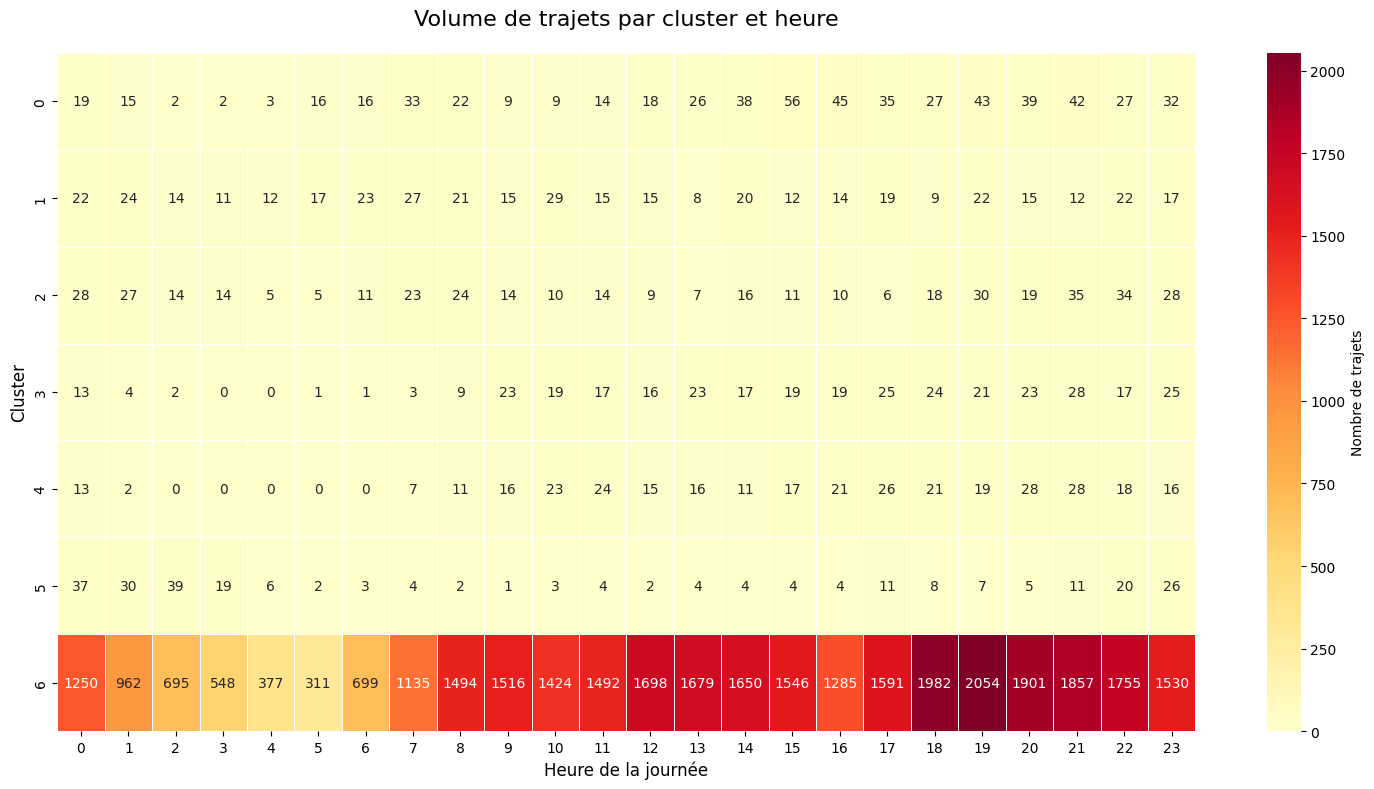

In [86]:


# Créer le pivot et remplacer les NaN par 0
pivot = summary.pivot(index='cluster', columns='hour', values='n_trips')
pivot = pivot.fillna(0)  # Remplacer les NaN par 0

# Vérifier qu'il n'y a plus de valeurs manquantes
print("Valeurs manquantes après imputation :", pivot.isna().sum().sum())

# Créer la heatmap améliorée
plt.figure(figsize=(15, 8))
sns.heatmap(pivot.astype(int),  # Convertir en entier maintenant qu'on a plus de NaN
           annot=True,              # Afficher les valeurs numériques
           fmt='d',                 # Format entier (maintenant ça marchera)
           cmap="YlOrRd",           # Palette plus contrastée
           cbar_kws={'label': 'Nombre de trajets'},
           linewidths=0.5)          # Séparateurs entre cellules

plt.title("Volume de trajets par cluster et heure", fontsize=16, pad=20)
plt.xlabel("Heure de la journée", fontsize=12)
plt.ylabel("Cluster", fontsize=12)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


<div style="background-color: #eddcd4ff; padding: 10px; border-radius: 5px; border-left: 4px solid #a77428ff;">
<h2 style="color: #572415ff; margin: 0;">Sauvegarde du model</h2>
</div>

<div style="background-color: #dfedd4ff; padding: 10px; border-radius: 5px; border-left: 4px solid #3ba728ff;">
<h4 style="color: #15574fff; margin: 0;">importer la bibliothéque de sauvegarde</h4>
</div>

In [87]:
import joblib

<div style="background-color: #dfedd4ff; padding: 10px; border-radius: 5px; border-left: 4px solid #3ba728ff;">
<h4 style="color: #15574fff; margin: 0;">sauvegarde du model</h4>
</div>

In [88]:
# sauvegarde
# joblib.dump(hdb, "hdbscan_model.pkl")

<div style="background-color: #eddcd4ff; padding: 10px; border-radius: 5px; border-left: 4px solid #a77428ff;">
<h2 style="color: #572415ff; margin: 0;">Exporter la base de données</h2>
</div>

In [90]:
# Supposons que ton DataFrame final s'appelle df
df.to_csv("uber_cleaned_clustered.csv", index=False)
